# EarthCARE — Nuages d'eau surfondue au-dessus du Dôme C
> Satellite ACM_CLP_2B | Station Concordia (−75.1°N / 123.35°E) | Été austral 2025–2026

## 0. Imports et configuration

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import (
    ORBIT_FRAME, DATE_START, DATE_END, JAXA_DATA_DIR,
    T_MIN, T_MAX, DOWNLOAD_PERIODS, HDF5_FIELDS_ORBIT_META,
    ORBIT_CACHE, GRID_CACHE, ALL_PARAMS,
)
from data_io import (
    download_product, download_multi_period,
    search_product, load_orbit, load_multi_orbits,
    load_jaxa_orbits, merge_orbit_sources, get_t0_utc,
)
from processing import prepare_single_orbit, prepare_multi_orbits, extract_circle_timeseries
from orbits_nc  import save_raw_orbits, load_raw_orbits, iter_raw_orbits, describe_raw_nc
from gridding   import GridAccumulator
from plotting   import (
    plot_cloud_classification, plot_temperature,
    plot_temperature_and_classification,
    plot_ice_water_content, plot_liquid_water_content,
    plot_water_paths, plot_lat_lon, plot_distance,
    plot_polar_scatter, plot_multi_orbit_scatter,
    orbites_above_threshold,
    plot_temporal_lwp_iwp,
    plot_grid_count, plot_grid_count_histogram,
    plot_grid_results, plot_grid_mean, plot_grid_std, plot_grid_lwp_iwp,
    plot_grid_mean_std_se,
    plot_lwp_timeseries_orbites, plot_lwp_timeseries, plot_circle_timeseries,
)

---
## 1. Analyse d'une seule orbite
> Orbite du **30 décembre 2025** — frame `09039G`

### 1.1 Téléchargement

In [ ]:
download_product(ORBIT_FRAME, DATE_START, DATE_END)

### 1.2 Chargement et préparation

In [ ]:
ds = search_product(DATE_START, DATE_END, orbit_and_frame=ORBIT_FRAME)
display(ds)

fp     = ds.filepath[0]
t0_utc = get_t0_utc(fp)
raw    = load_orbit(fp)
d      = prepare_single_orbit(raw, t0_utc)
d["t0_utc"] = t0_utc

print(f"Fichier       : {fp}")
print(f"particle_type : {d['particle_type'].shape}")
print(f"temperature   : {d['temperature'].shape}")
print(f"height        : {d['height'].shape}")

### 1.3 Profils verticaux

In [ ]:
plot_cloud_classification(d, T_MIN, T_MAX)

In [ ]:
plot_temperature(d, T_MIN, T_MAX)

In [ ]:
plot_temperature_and_classification(d, T_MIN, T_MAX)

In [ ]:
plot_ice_water_content(d, T_MIN, T_MAX)

In [ ]:
plot_liquid_water_content(d, T_MIN, T_MAX)

In [ ]:
plot_water_paths(d, T_MIN, T_MAX)

### 1.4 Géolocalisation

In [ ]:
plot_lat_lon(d, T_MIN, T_MAX)

In [ ]:
plot_distance(d)

### 1.5 Carte polaire (orbite unique)

In [ ]:
plot_polar_scatter(
    d["lon"], d["lat"], d["lwp_plot"],
    title="Liquid Water Path", cbar_label="LWP ($g/m²$)",
    t_utc_start=d["t_utc_start"], t_utc_end=d["t_utc_end"],
    vmin=0, vmax=50,
)

In [ ]:
plot_polar_scatter(
    d["lon"], d["lat"], d["iwp_plot"],
    title="Ice Water Path", cbar_label="IWP ($g/m²$)",
    t_utc_start=d["t_utc_start"], t_utc_end=d["t_utc_end"],
    vmin=0, vmax=50,
)

---
## 2. Pipeline multi-orbites
> Période : `2025-12-01` → `2026-02-01`

### 2.1 Téléchargement (ESA)

In [ ]:
download_multi_period(DOWNLOAD_PERIODS, frame_id="G")

### 2.2 Chargement ESA + JAXA

In [ ]:
ds_multi = search_product(DATE_START, DATE_END, all_frames=True)
display(ds_multi)

esa_raw  = load_multi_orbits(ds_multi.filepath, extra_fields=HDF5_FIELDS_ORBIT_META)
jaxa_raw = load_jaxa_orbits(JAXA_DATA_DIR,      extra_fields=HDF5_FIELDS_ORBIT_META)
all_raw  = merge_orbit_sources(esa_raw, jaxa_raw, sort_by="start_time")
print(f"{len(all_raw)} orbites chargées (ESA + JAXA)")

### 2.3 Processing → NetCDF intermédiaire
> `prepare_multi_orbits` → `save_raw_orbits` — une seule lecture des HDF5

In [ ]:
orbites = prepare_multi_orbits(all_raw)
print(f"{len(orbites)} orbites préparées")

In [ ]:
from datetime import datetime, timedelta
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
from processing import haversine

RADIUS_KM  = 500
EPOCH_2000 = datetime(2000, 1, 1, 0, 0, 0)

times_all, lwp_all, dist_all = [], [], []
for orb in orbites:
    lat  = np.asarray(orb["lat"],  dtype=float)
    lon  = np.asarray(orb["lon"],  dtype=float)
    lwp  = np.asarray(orb["lwp"],  dtype=float)
    time = np.asarray(orb["time"], dtype=np.float64)

    dist = haversine(lat, lon, -75.1, 123.35)

    # time > 0 exclut les 0.0 de padding en fin de tableau
    mask = (dist <= RADIUS_KM) & (time > 0.0)
    if not np.any(mask):
        continue

    times_all.extend([EPOCH_2000 + timedelta(seconds=float(t)) for t in time[mask]])
    lwp_all.append(np.where(lwp[mask] < 0, np.nan, lwp[mask]))
    dist_all.append(dist[mask])

lwp_all  = np.concatenate(lwp_all)
dist_all = np.concatenate(dist_all)

bounds = np.arange(0, RADIUS_KM + 50, 50)
norm   = mcolors.BoundaryNorm(bounds, plt.cm.rainbow.N)

fig, ax = plt.subplots(figsize=(16, 5))
sc = ax.scatter(times_all, lwp_all, s=6, c=dist_all, cmap="rainbow",
                norm=norm, linewidths=0, alpha=0.8)
cb = fig.colorbar(sc, ax=ax, label="Distance au Dôme C (km)")
cb.set_ticks(bounds)
ax.set_ylabel("LWP (g/m²)")
ax.set_xlabel("Date (UTC)")
ax.set_title(f"LWP vs temps — rayon {RADIUS_KM} km | {len(times_all)} footprints")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b\n%Y"))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Moyenne / Écart-type / Erreur sur la moyenne du LWP par bin horaire (option A : LWP=0 inclus)

In [ ]:
import pandas as pd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np

# ── Construire le DataFrame depuis les listes déjà calculées ──
df = pd.DataFrame({
    "time": times_all,
    "lwp":  lwp_all,          # LWP=0 inclus, NaN=invalide exclu
}).dropna(subset=["lwp"])     # retire uniquement les NaN (valeurs invalides)

df["hour_bin"] = df["time"].dt.floor("h")   # arrondi à l'heure inférieure

# ── Statistiques par bin horaire ──
stats = df.groupby("hour_bin")["lwp"].agg(
    mean="mean",
    std="std",
    n="count",
).reset_index()
stats["se"] = stats["std"] / np.sqrt(stats["n"])   # erreur sur la moyenne

# ── Figure ──
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
fig.patch.set_facecolor("white")
fig.suptitle(
    f"LWP horaire — rayon {RADIUS_KM} km autour du Dôme C (LWP=0 inclus)",
    fontsize=12, fontweight="bold", color="#003399"
)

labels = ["Moyenne (g/m²)", "Écart-type (g/m²)", "Erreur sur la moyenne (g/m²)"]
cols   = ["mean", "std", "se"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

for ax, col, label, color in zip(axes, cols, labels, colors):
    ax.bar(stats["hour_bin"], stats[col], width=1/24, color=color,
           alpha=0.8, align="edge")
    ax.set_ylabel(label, fontsize=9)
    ax.grid(axis="y", alpha=0.3)

n_days = (stats["hour_bin"].iloc[-1] - stats["hour_bin"].iloc[0]).days + 1
axes[-1].xaxis.set_major_locator(mdates.DayLocator(interval=max(1, n_days // 10)))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%d %b\n%Y"))
axes[-1].set_xlabel("Date (UTC)", fontsize=10)

plt.tight_layout()
plt.show()

print(f"Bins horaires : {len(stats)}")
print(stats[["hour_bin", "mean", "std", "se", "n"]].head(10).to_string(index=False))

In [ ]:
save_raw_orbits(orbites, ORBIT_CACHE)
describe_raw_nc(ORBIT_CACHE)

### 2.4 Gridding → cache grille
> Lecture orbite par orbite depuis `ORBIT_CACHE` — pas de chargement en RAM

In [ ]:
def run_grid(force_rebuild: bool = False) -> GridAccumulator:
    cache_path = Path(GRID_CACHE)
    if not force_rebuild and cache_path.exists():
        print(f"[grid] Cache existant : {cache_path}")
        return GridAccumulator.load(str(cache_path))

    print("[grid] Construction depuis ORBIT_CACHE...")
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    grid  = GridAccumulator(dlat=1.0, dlon=10.0)
    total = sum(1 for _ in iter_raw_orbits(ORBIT_CACHE))
    for i, orb in enumerate(iter_raw_orbits(ORBIT_CACHE), 1):
        grid.accumulate(orb)
        if i % 10 == 0 or i == total:
            print(f"  {i}/{total} orbites accumulées")
            grid.save(str(cache_path))
    print(f"[grid] Terminé — {grid}")
    return grid

grid = run_grid(force_rebuild=False)

---
## 3. Exploration des orbites brutes

### 3.1 Scatter polaire — LWP, IWP, élévation

In [ ]:
plot_multi_orbit_scatter(orbites, "lwp",               n_orbites_label=len(orbites))

In [ ]:
plot_multi_orbit_scatter(orbites, "iwp",               n_orbites_label=len(orbites))

In [ ]:
plot_multi_orbit_scatter(orbites, "surface_elevation",  n_orbites_label=len(orbites))

### 3.2 Orbites avec LWP au-dessus d'un seuil

In [ ]:
orbites_above_threshold(orbites, param="lwp", threshold=100.0, plot=True)

---
## 4. Statistiques sur grille

### 4.1 Chargement de la grille

In [2]:
GRID_CACHE = "./data/grid_cache_orbit_1_5.nc"

In [3]:
grid = GridAccumulator.load(str(GRID_CACHE))

Chargé : ./data/grid_cache_orbit_1_5.nc
       62 jours | 2760 orbites | 2025-12-01 -> 2026-01-31


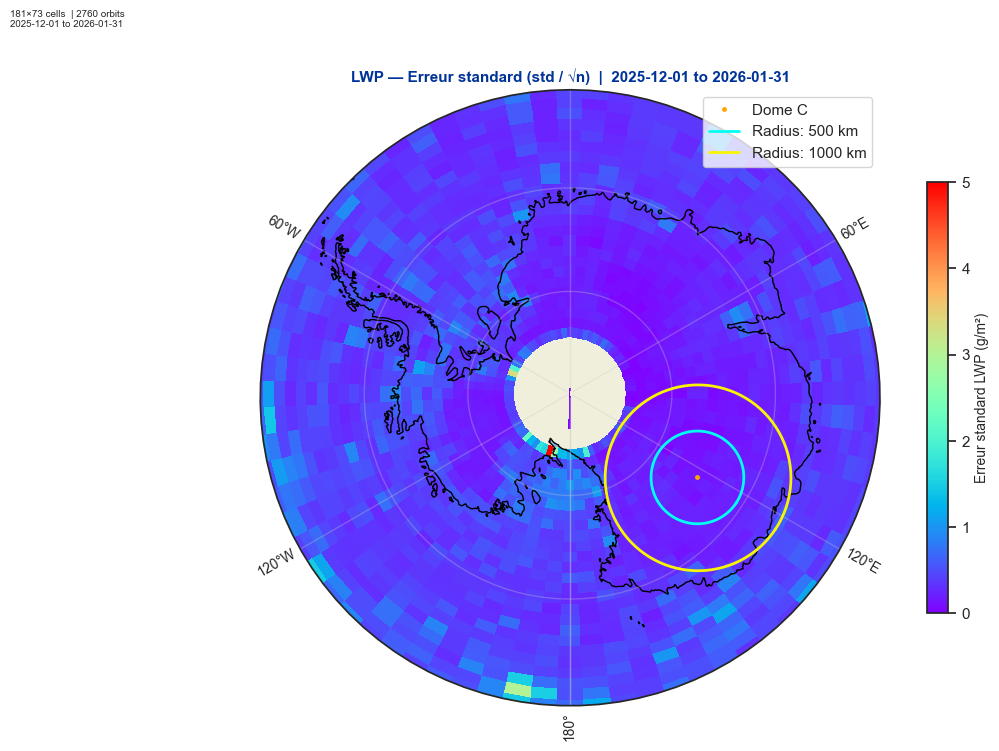

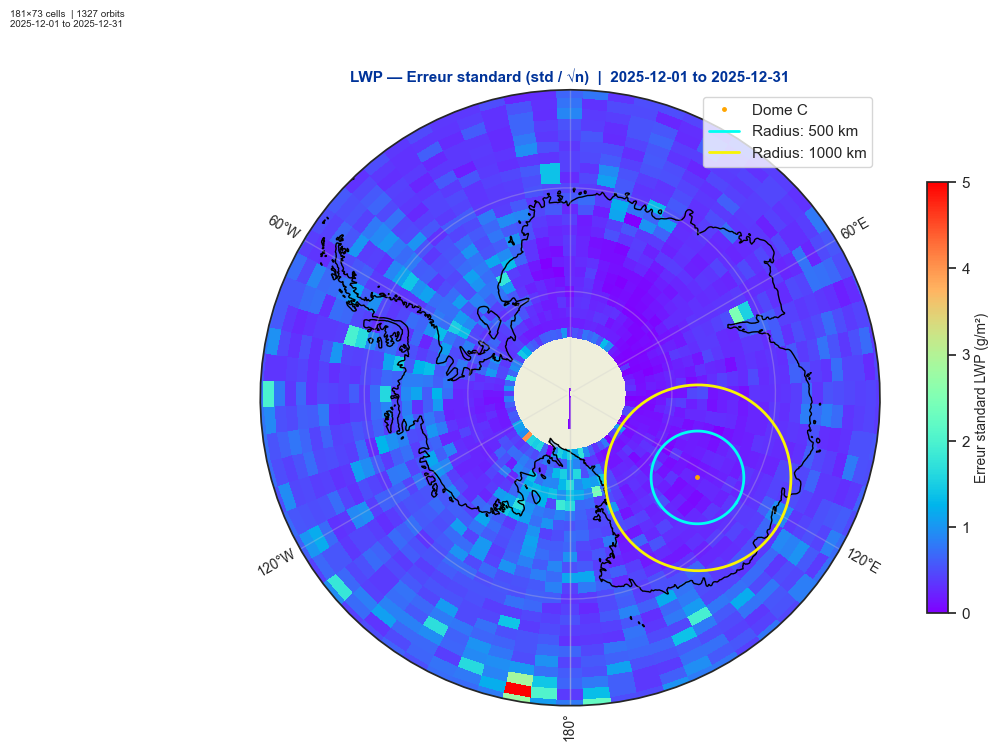

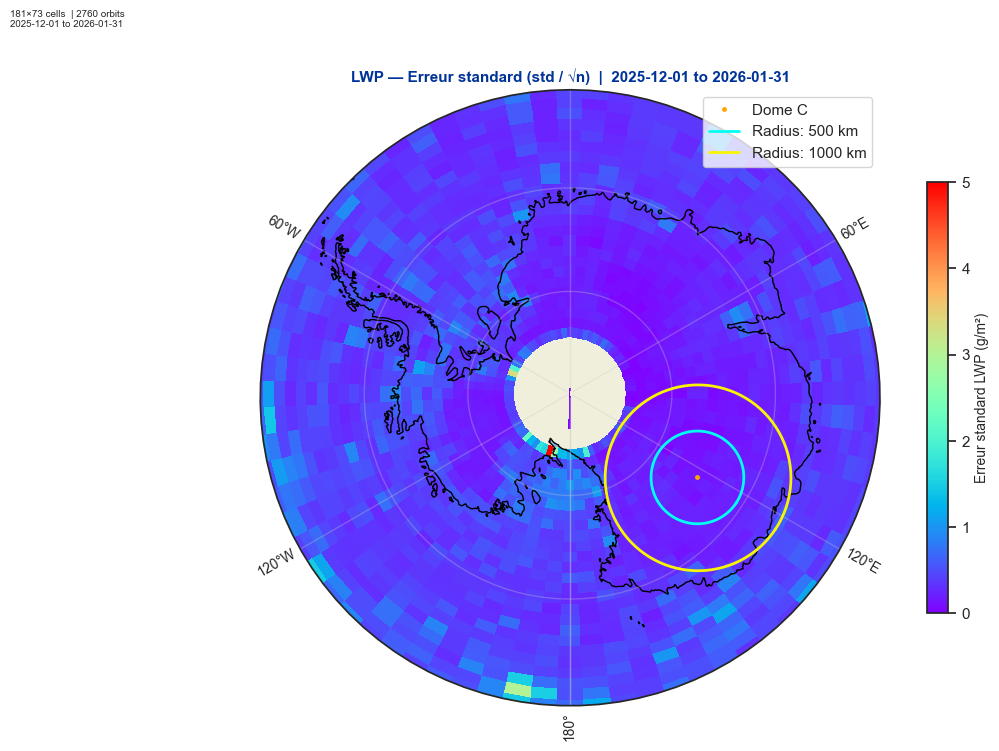

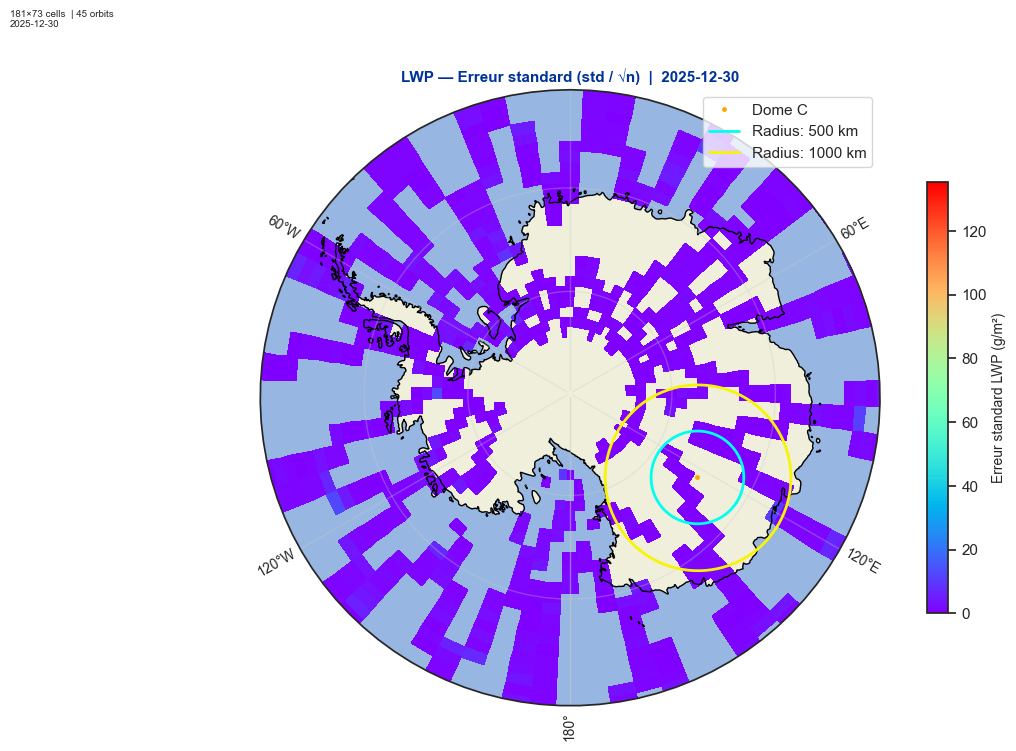

In [ ]:
from plotting import plot_grid_standard_error

# LWP — toute la période
plot_grid_standard_error(grid, param="lwp",vmax=5)

# IWP — sur une plage précise
plot_grid_standard_error(grid, param="lwp", d1="2025-12-01", d2="2025-12-31", vmax=3)

# Fixer l'échelle manuellement
plot_grid_standard_error(grid, param="lwp", vmax=5)

# Pour un jour précis
plot_grid_standard_error(grid, param="lwp", day="2025-12-30")


### 4.2 Nombre d'observations par cellule

In [ ]:
plot_grid_count(grid, param="lwp", d1=DATE_START, d2=DATE_END)
plot_grid_count(grid, param="iwp", d1=DATE_START, d2=DATE_END)

In [ ]:
plot_grid_count_histogram(grid, param="lwp", d1=DATE_START, d2=DATE_END)

### 4.3 Moyenne

In [ ]:
plot_grid_mean(grid, param="lwp",               cbar_label="LWP ($g/m²$)",   vmin=0, vmax=20,   d1=DATE_START, d2=DATE_END)
plot_grid_mean(grid, param="iwp",               cbar_label="IWP ($g/m²$)",   vmin=0, vmax=100,  d1=DATE_START, d2=DATE_END)
plot_grid_mean(grid, param="surface_elevation",  cbar_label="Elevation (m)",  vmin=0, vmax=4000, d1=DATE_START, d2=DATE_END)

### 4.4 Écart-type

In [ ]:
plot_grid_std(grid, param="lwp", vmin=0, vmax=20, d1=DATE_START, d2=DATE_END)
plot_grid_std(grid, param="iwp", vmin=0, vmax=50, d1=DATE_START, d2=DATE_END)

### 4.5 Panel LWP + IWP (moyenne et écart-type)

In [ ]:
plot_grid_lwp_iwp(grid, d1=DATE_START, d2=DATE_END)

### 4.6 Moyenne / Écart-type / Erreur sur la moyenne (côte à côte)

In [ ]:
# LWP — décembre 2025 — deux pentes linéaires
plot_grid_mean_std_se(grid, param="lwp",
                      twoslope_mean=(0,  50,  300),   # linéaire [0→50] puis [50→300]
                      twoslope_std= (0,  50,  300),
                      twoslope_se=  (0,   1,   10),
                      twoslope_n=   (0, 200, 2000),
                      d1="2025-12-01", d2="2025-12-31")

# IWP — décembre 2025
plot_grid_mean_std_se(grid, param="iwp",
                      twoslope_mean=(0,  50,  300),
                      twoslope_std= (0,  50,  300),
                      twoslope_se=  (0,   5,   20),
                      twoslope_n=   (0, 200, 2000),
                      d1="2025-12-01", d2="2025-12-31")

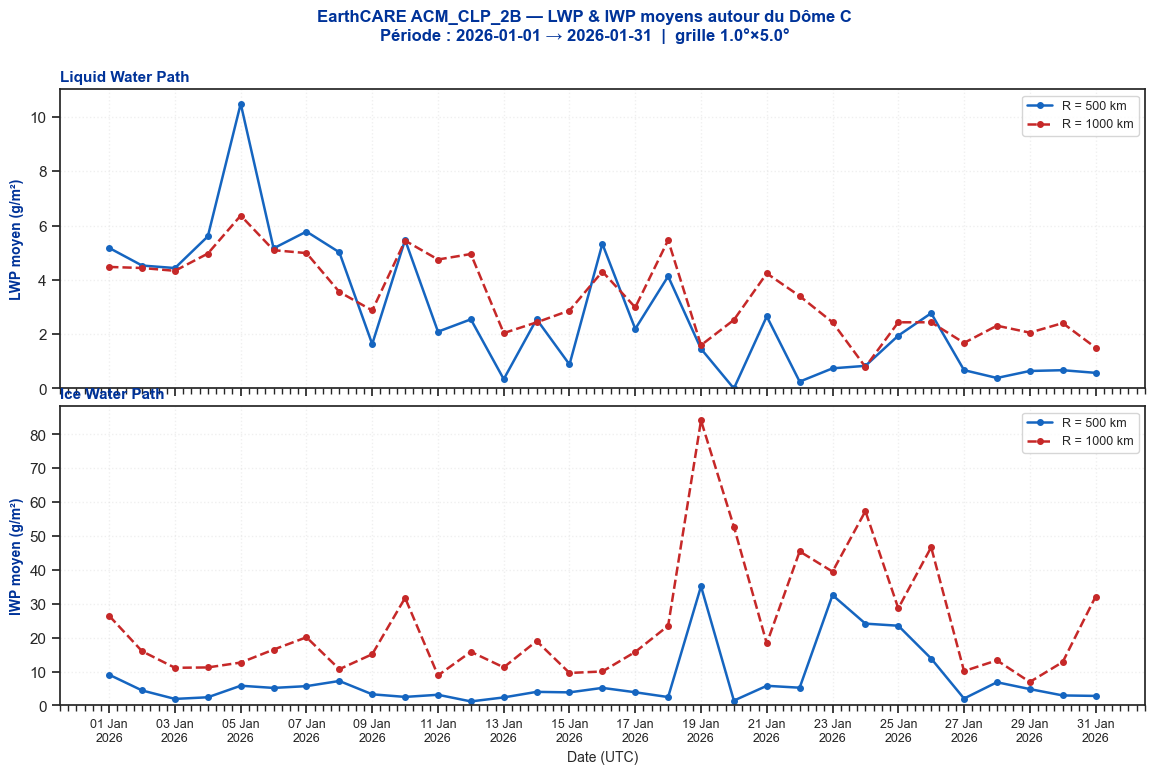

In [5]:
plot_temporal_lwp_iwp(grid, d1="2026-01-01", d2="2026-01-31")


In [ ]:
plot_temporal_lwp_iwp(grid, d1="2025-12-01", d2="2025-12-15", mode="heure")


---
## 5. Série temporelle dans un cercle autour du Dôme C

In [ ]:
plot_lwp_timeseries(ORBIT_CACHE, radius_km=500,  d1="2025-12-01", d2="2025-12-31")
plot_lwp_timeseries(ORBIT_CACHE, radius_km=1000, d1="2025-12-01", d2="2025-12-31")

In [ ]:
# Série temporelle — 500 km, échelle log sur IWC/LWC
plot_circle_timeseries(ts_500, iwc_log=True, lwc_log=True,
                       temp_vmin=-60, temp_vmax=-10)

# Pour 1000 km
ts_1000 = extract_circle_timeseries(ORBIT_CACHE, radius_km=1000,
                                     d1="2025-12-01", d2="2025-12-31")
plot_circle_timeseries(ts_1000, iwc_log=True, lwc_log=True,
                       temp_vmin=-60, temp_vmax=-10)